In [6]:
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
filepath="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

In [7]:
df = pd.read_csv(filepath, header=0)
df.head(4)

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.5280,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.8510,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.8510,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.6901,1244,Low,0,1


(0.0, 3974.15)

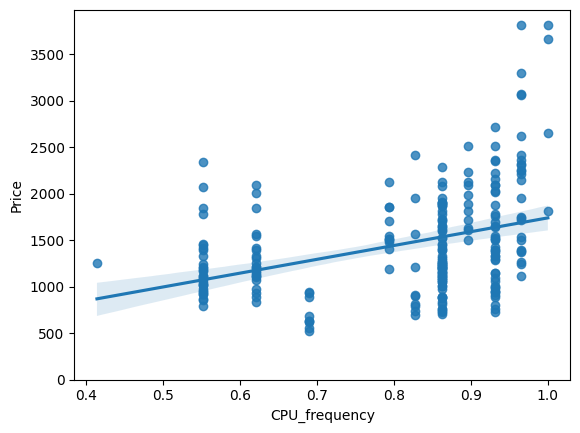

In [11]:
sns.regplot(x='CPU_frequency', y='Price', data=df)
plt.ylim(0.)

(0.0, 3974.15)

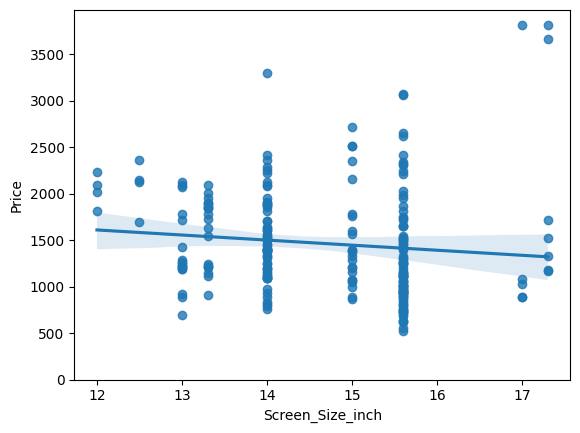

In [12]:
sns.regplot(x='Screen_Size_inch', y='Price', data=df)
plt.ylim(0,)

(0.0, 3974.15)

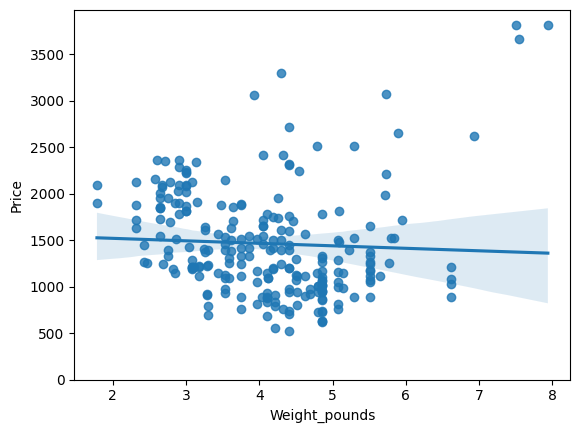

In [13]:
sns.regplot(x="Weight_pounds", y="Price", data=df)
plt.ylim(0,)

In [14]:
for param in ["CPU_frequency", "Screen_Size_inch","Weight_pounds"]:
    print(f"Correlation of Price and {param} is ", df[[param,"Price"]].corr())

Correlation of Price and CPU_frequency is                 CPU_frequency     Price
CPU_frequency       1.000000  0.366666
Price               0.366666  1.000000
Correlation of Price and Screen_Size_inch is                    Screen_Size_inch     Price
Screen_Size_inch          1.000000 -0.110644
Price                    -0.110644  1.000000
Correlation of Price and Weight_pounds is                 Weight_pounds     Price
Weight_pounds       1.000000 -0.050312
Price              -0.050312  1.000000


<Axes: xlabel='Category', ylabel='Price'>

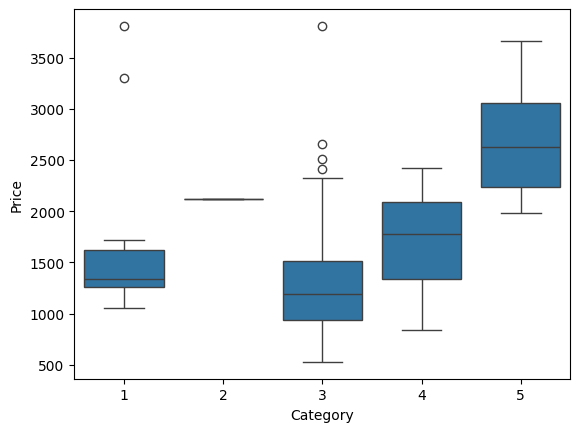

In [15]:
sns.boxplot(x="Category", y="Price", data=df)

<Axes: xlabel='GPU', ylabel='Price'>

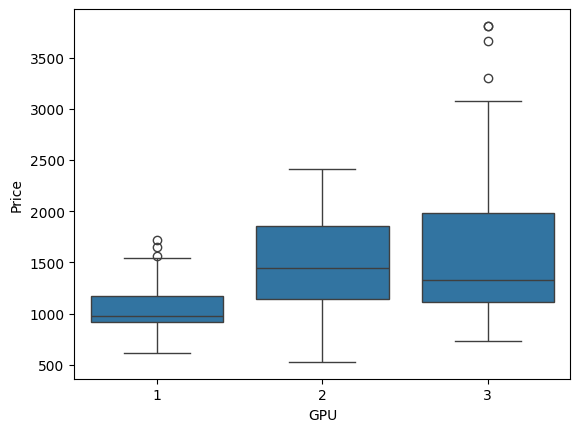

In [16]:
sns.boxplot(x="GPU", y="Price", data=df)

In [23]:
df_group = df[["GPU", "CPU_core" , "Price"]]
df_group_test1 = df_group.groupby(["GPU", "CPU_core"], as_index=False).mean()

In [24]:
grouped_pivot = df_group_test1.pivot(index='GPU',columns='CPU_core')
print(grouped_pivot)

               Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


In [25]:
for param in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU','Category']:
    pearson_coef, p_value = stats.pearsonr(df[param], df['Price'])
    print(param)
    print("The Pearson Correlation Coefficient for ",param," is", pearson_coef, " with a P-value of P =", p_value)

RAM_GB
The Pearson Correlation Coefficient for  RAM_GB  is 0.5492972971857844  with a P-value of P = 3.681560628842808e-20
CPU_frequency
The Pearson Correlation Coefficient for  CPU_frequency  is 0.36666555892588604  with a P-value of P = 5.502463350713339e-09
Storage_GB_SSD
The Pearson Correlation Coefficient for  Storage_GB_SSD  is 0.243420755218103  with a P-value of P = 0.00014898923191724036
Screen_Size_inch
The Pearson Correlation Coefficient for  Screen_Size_inch  is -0.11064420817118266  with a P-value of P = 0.08853397846830682
Weight_pounds
The Pearson Correlation Coefficient for  Weight_pounds  is -0.05031225837751549  with a P-value of P = 0.439769385343388
CPU_core
The Pearson Correlation Coefficient for  CPU_core  is 0.4593977773355115  with a P-value of P = 7.912950127009359e-14
OS
The Pearson Correlation Coefficient for  OS  is -0.22172980114827384  with a P-value of P = 0.0005696642559246739
GPU
The Pearson Correlation Coefficient for  GPU  is 0.2882981988881427  with 